<div align = "right">
10 / 04 / 26
<div style = "height: 20px;"></div>
<span style = "color:orange"> <strong>Reconocimiento de Patrones </strong></span>
<style>div[align = "right"]{font-family: 'Montserrat', sans-serif;}</style></div>

<h1 style = "color: orange"><strong> Práctica 3: Selección de características</strong></h1>

In [107]:
# Bibliotecas
import os
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import LinearSVC
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import (accuracy_score, confusion_matrix, roc_auc_score)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score

%matplotlib inline
matplotlib.use('module://matplotlib_inline.backend_inline', force = True)


In [108]:
# Ruta donde se guardarán las imágenes del reporte
RUTA_IMG = '/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img'
os.makedirs(RUTA_IMG, exist_ok = True)

RANDOM_STATE = 43
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 200

In [ ]:
def guardar_figura(nombre):
    """Guarda la figura activa en RUTA_IMG con el nombre dado (.png)."""
    ruta = os.path.join(RUTA_IMG, nombre)
    plt.savefig(ruta, dpi = 300, bbox_inches = 'tight')
    print(f'{ruta}')

Se decidió usar le conjunto de datos ``arrhytmia``.

In [110]:
# Datos
ruta = 'arrhythmia.data'
df = pd.read_csv(ruta, header = None, na_values = '?')
df.sample(3)

,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
55,72,1,160,70,77,142,392,160,88,30,...,0.0,9.0,0.0,0.0,0.0,0.5,2.6,27.0,46.7,6
15,47,1,150,48,75,132,350,169,65,36,...,0.0,7.7,-0.8,0.0,0.0,0.6,1.7,17.2,31.1,1
166,68,1,168,59,78,159,356,164,83,-51,...,0.0,7.0,-2.7,0.0,0.0,0.4,2.6,6.2,31.1,1


:0



In [111]:
columnas = (
    ['age', 'sex', 'height', 'weight', 'qrs_duration', 'pr_interval',
     'qt_interval', 't_interval', 'p_interval', 'qrs_angle', 't_angle',
     'p_angle', 'qrst_angle', 'j_angle', 'heart_rate'] + [f'a_{i}' for i in range(16, 280)] + ['class'])

df_arr = pd.read_csv(ruta, header = None, names = columnas, na_values = '?')
df_arr.sample(3)

,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,...,a_271,a_272,a_273,a_274,a_275,a_276,a_277,a_278,a_279,class
188,22,1,165,52,108,184,406,218,114,24,...,-0.7,23.6,-3.4,0.0,0.0,0.6,-2.4,54.0,22.4,14
324,38,0,170,69,91,164,357,172,78,-60,...,0.0,3.9,-1.7,0.0,0.0,0.6,1.5,4.8,18.0,10
10,62,0,170,72,102,135,401,156,83,72,...,-0.5,9.0,-2.0,0.0,0.0,0.8,0.9,12.3,19.3,3


In [112]:
df_arr1 = df_arr[['age', 'sex', 'height', 'weight', 'qrs_duration', 'pr_interval', 'qt_interval', 
                  't_interval', 'p_interval', 'qrs_angle', 't_angle', 'p_angle', 'qrst_angle', 
                  'j_angle', 'heart_rate']]

df_arr1.sample(3)

,age,sex,height,weight,qrs_duration,pr_interval,qt_interval,t_interval,p_interval,qrs_angle,t_angle,p_angle,qrst_angle,j_angle,heart_rate
323,54,0,164,83,107,182,359,241,127,4,-163.0,44.0,-16.0,-168.0,76.0
161,42,1,160,68,81,147,337,131,96,-1,-1.0,46.0,-1.0,NaN,85.0
201,64,1,160,80,62,160,376,136,104,4,52.0,5.0,15.0,NaN,68.0


In [113]:
reporte = ProfileReport(df_arr1, title = 'Perfilamiento de Datos', explorative = True)

In [ ]:
# reporte

In [115]:
rep_html = reporte.to_file('reporte_datos.html')

/home/ibra/venv_ds/lib/python3.10/site-packages/ydata_profiling/utils/dataframe.py:137: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.rename(columns={"index": "df_index"}, inplace=True)


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 156894.16it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

In [116]:
# Valores faltantes
contador_nan = df.isna().sum()
print('Columnas con NaN:')
print(contador_nan[contador_nan > 0].sort_values(ascending = False))

Columnas con NaN:
13    376
11     22
10      8
12      1
14      1
dtype: int64


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img/01_distribucion_clases.png


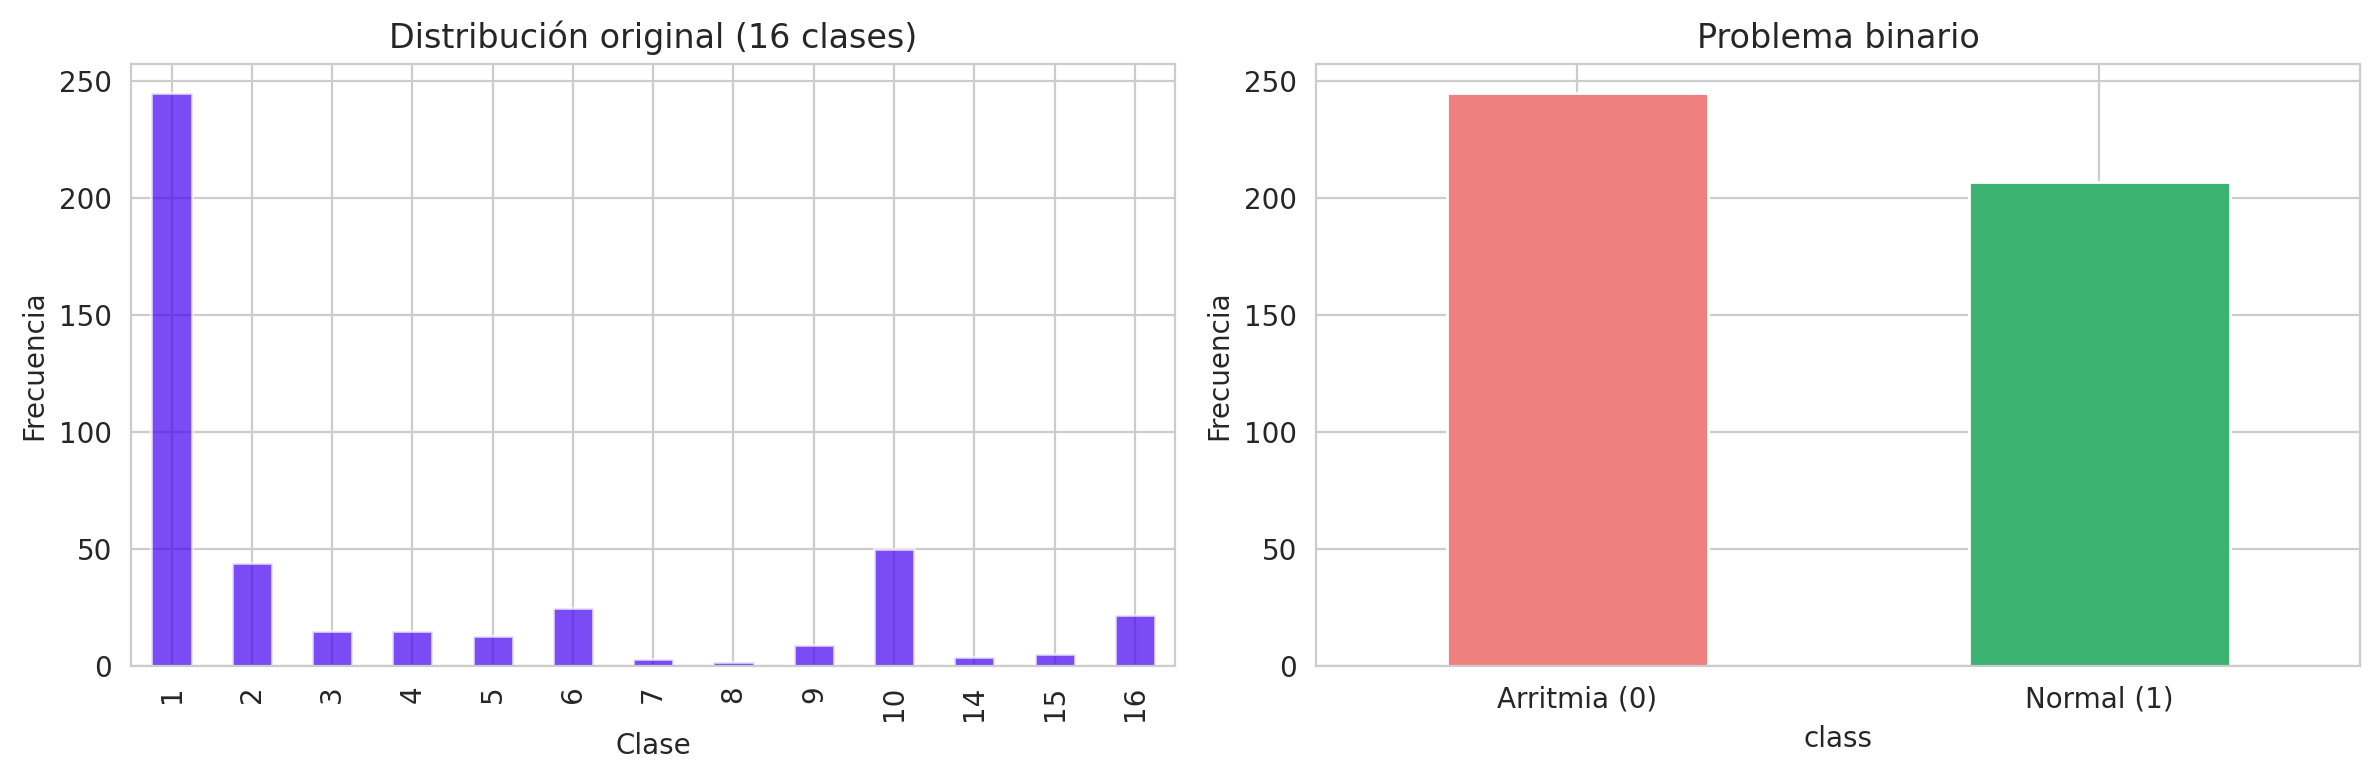

Ratio normal/arritmia: 0.542


In [117]:
# Distribución de clases
fig, axes = plt.subplots(1, 2, figsize = (12, 4))

df_arr['class'].value_counts().sort_index().plot(
    kind = 'bar', ax = axes[0], color = '#4300F3', alpha = 0.7
)
axes[0].set_title('Distribución original (16 clases)')
axes[0].set_xlabel('Clase')
axes[0].set_ylabel('Frecuencia')

# Reformulación binaria
y_bin = (df_arr['class'] == 1).astype(int)
y_bin.value_counts().plot(
    kind = 'bar', ax = axes[1], color = ['lightcoral', 'mediumseagreen']
)
axes[1].set_xticklabels(['Arritmia (0)', 'Normal (1)'], rotation = 0)
axes[1].set_title('Problema binario')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
guardar_figura('01_distribucion_clases.png')
plt.show()

print(f'Ratio normal/arritmia: {y_bin.mean():.3f}')


In [118]:
# a) Eliminar columnas inútiles y columnas con varianza cero
X_full = df_arr.drop(columns = ['class', 'j_angle'])
y = y_bin.values

# Columnas constantes
const_cols = X_full.columns[X_full.nunique() <= 1].tolist()
print(f'Columnas constantes eliminadas: {len(const_cols)}')
X_full = X_full.drop(columns = const_cols)

Columnas constantes eliminadas: 17


In [119]:
# b)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_full, y, 
    test_size = 0.20, 
    stratify = y, 
    random_state = RANDOM_STATE
)

print(f'Proporción normal en train: {y_train.mean():.3f}')
print(f'Proporción normal en test: {y_test.mean():.3f}')

Proporción normal en train: 0.543
Proporción normal en test: 0.538


In [120]:
# c) Imputación + escalado z-score
imputer = SimpleImputer(strategy = 'median')
X_train_imp = imputer.fit_transform(X_train_raw)
X_test_imp  = imputer.transform(X_test_raw)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_imp)
X_test = scaler.transform(X_test_imp)

# Volvemos a DataFrame para conservar nombres de columnas
feat_names = X_full.columns.tolist()
X_train = pd.DataFrame(X_train, columns = feat_names, index = X_train_raw.index)
X_test = pd.DataFrame(X_test, columns = feat_names, index = X_test_raw.index)

print(f'Media tras z-score (train): {X_train.values.mean():.2e}')
print(f'Std tras z-score (train): {X_train.values.std():.3f}')

Media tras z-score (train): -1.09e-18
Std tras z-score (train): 0.988


In [121]:
# Clasificador base y esquema de CV que reutilizaremos
def base_svm():

    return LinearSVC(C = 1.0, 
                     dual = 'auto', 
                     max_iter = 5000, 
                     random_state = RANDOM_STATE)

In [122]:
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = RANDOM_STATE)

baseline_scores = cross_val_score(base_svm(), X_train, y_train, cv = cv, scoring = 'accuracy')

print(f'Baseline (todas las features) — CV accuracy: '
      f'{baseline_scores.mean():.4f} +/- {baseline_scores.std():.4f}')
print(f'Características: {X_train.shape[1]}')

Baseline (todas las features) — CV accuracy: 0.6731 +/- 0.0452
Características: 261


## SFS

In [123]:
def sfs_manual(X, y, max_caracteristicas = 20, paciencia = 3, cv = None):
    """Búsqueda Secuencial hacia delante (implementación manual).

    Parámetros
    ----------
    X, y : datos y etiquetas.
    max_caracteristicas : tope superior de features a añadir.
    paciencia : nº de iteraciones sin mejora antes de detener (early stopping).
    cv : esquema de validación cruzada.

    Devuelve
    --------
    mejor_subconjunto : lista de features en el subconjunto óptimo.
    historial : lista de tuplas (feature_añadida, accuracy_cv).
    mejor_score : exactitud CV del mejor subconjunto.
    """
    restantes = list(X.columns)
    seleccionadas = []
    historial = []
    mejor_score = -np.inf
    rondas_sin_mejora = 0
    mejor_subconjunto = []

    for paso in range(max_caracteristicas):

        mejor_score_paso = -np.inf
        mejor_feat_paso = None

        for feat in restantes:

            candidatas = seleccionadas + [feat]
            scores = cross_val_score(base_svm(), X[candidatas], y, cv = cv, scoring = 'accuracy', n_jobs = -1)
            s = scores.mean()

            if s > mejor_score_paso:

                mejor_score_paso = s
                mejor_feat_paso = feat

        seleccionadas.append(mejor_feat_paso)
        restantes.remove(mejor_feat_paso)
        historial.append((mejor_feat_paso, mejor_score_paso))
        print(f'[{paso+1:2d}] + {mejor_feat_paso:<15s} acc = {mejor_score_paso:.4f}')

        if mejor_score_paso > mejor_score + 1e-6:

            mejor_score = mejor_score_paso
            mejor_subconjunto = seleccionadas.copy()
            rondas_sin_mejora = 0

        else:

            rondas_sin_mejora += 1

            if rondas_sin_mejora >= paciencia:

                print(f'>> Early stopping en iteración {paso+1}'
                      f'({paciencia} iteraciones sin mejora).')
                break

    return mejor_subconjunto, historial, mejor_score


In [ ]:
# SFS con sklearn para comparar con la implementación manual
sfs_sklearn = SequentialFeatureSelector(
    estimator = base_svm(),
    n_features_to_select = 'auto',
    tol = 1e-3,
    direction = 'forward',
    scoring = 'accuracy',
    cv = cv,
    n_jobs = -1,
)
sfs_sklearn.fit(X_train, y_train)

sfs_sk_features = X_train.columns[sfs_sklearn.get_support()].tolist()
sfs_sk_cv = cross_val_score(base_svm(), X_train[sfs_sk_features], y_train, cv = cv, scoring = 'accuracy')

sfs_sk_best_cv = sfs_sk_cv.mean()

print(f'CV accuracy: {sfs_sk_best_cv:.4f} +/- {sfs_sk_cv.std():.4f}')
print(f'Features: {sfs_sk_features}')

CV accuracy: 0.7755 +/- 0.0352
Features: ['qrs_duration', 'a_44', 'a_61', 'a_103', 'a_114', 'a_169', 'a_250']


In [125]:
sfs_features, sfs_history, sfs_best_cv = sfs_manual(
    X_train, y_train,
    max_caracteristicas = 20,
    paciencia = 3,
    cv = cv,
)
print(f'\nSFS manual: {len(sfs_features)} features, CV acc = {sfs_best_cv:.4f}')


[ 1] + qrs_duration    acc = 0.6842
[ 2] + a_169           acc = 0.7145
[ 3] + a_103           acc = 0.7450
[ 4] + a_114           acc = 0.7506
[ 5] + a_250           acc = 0.7643
[ 6] + a_61            acc = 0.7727
[ 7] + a_44            acc = 0.7755
[ 8] + height          acc = 0.7755
[ 9] + a_73            acc = 0.7782
[10] + a_22            acc = 0.7782
[11] + a_25            acc = 0.7782
[12] + a_26            acc = 0.7782
>> Early stopping en iteración 12(3 iteraciones sin mejora).

SFS manual: 9 features, CV acc = 0.7782


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img/02_sfs_curva.png


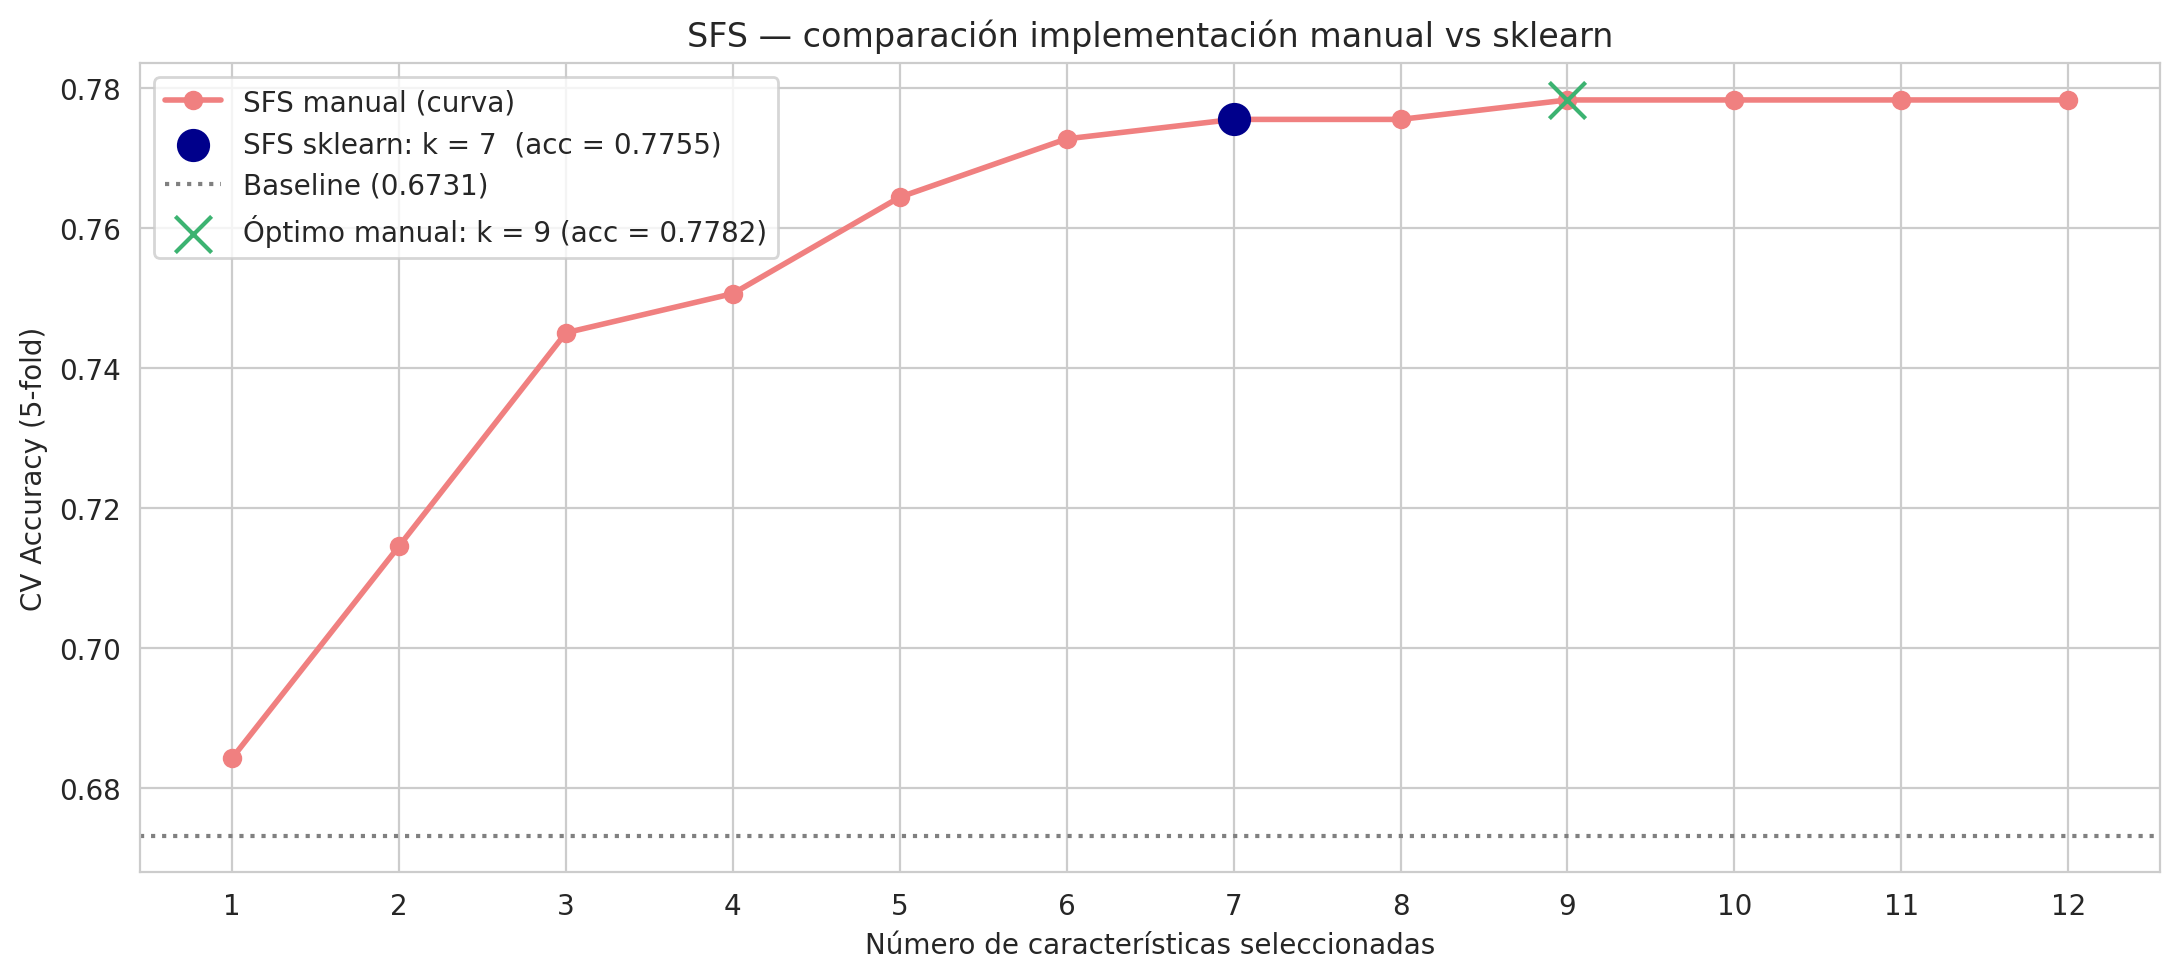


Features seleccionadas por SFS manual:
   1. qrs_duration
   2. a_169
   3. a_103
   4. a_114
   5. a_250
   6. a_61
   7. a_44
   8. height
   9. a_73

Features seleccionadas por SFS sklearn:
   1. qrs_duration
   2. a_44
   3. a_61
   4. a_103
   5. a_114
   6. a_169
   7. a_250

Intersección SFS manual y sklearn: 7 features
['a_103', 'a_114', 'a_169', 'a_250', 'a_44', 'a_61', 'qrs_duration']


In [ ]:
# Curva SFS manual + punto SFS sklearn sobreimpuesto
feats_anadidas = [h[0] for h in sfs_history]
scores_hist = [h[1] for h in sfs_history]

plt.figure(figsize = (11, 5))
plt.plot(
    range(1, len(scores_hist) + 1), scores_hist,
    marker = 'o', linewidth = 2, color = 'lightcoral',
    label = 'SFS manual (curva)'
)


# Punto de la versión sklearn
plt.scatter(
    [len(sfs_sk_features)], [sfs_sk_best_cv],
    color = 'darkblue', s = 120, zorder = 5,
    label = f'SFS sklearn: k = {len(sfs_sk_features)}  (acc = {sfs_sk_best_cv:.4f})'
)

# Baseline
plt.axhline(baseline_scores.mean(), color = 'gray', linestyle = ':', label = f'Baseline ({baseline_scores.mean():.4f})')

# Óptimo de la versión manual
k_manual = len(sfs_features)
plt.scatter(k_manual, 0.7782, color = 'mediumseagreen', marker = 'x', s = 170, zorder = 5, label = f'Óptimo manual: k = {k_manual} (acc = {sfs_best_cv:.4f})')

plt.xlabel('Número de características seleccionadas')
plt.ylabel('CV Accuracy (5-fold)')
plt.title('SFS — comparación implementación manual vs sklearn')
plt.xticks(range(1, len(scores_hist) + 1))
plt.legend()
plt.tight_layout()
guardar_figura('02_sfs_curva.png')
plt.show()

print('\nFeatures seleccionadas por SFS manual:')
for i, f in enumerate(sfs_features, 1):
    print(f'  {i:2d}. {f}')

print('\nFeatures seleccionadas por SFS sklearn:')
for i, f in enumerate(sfs_sk_features, 1):
    print(f'  {i:2d}. {f}')

# Intersección entre ambas versiones
coincidentes = set(sfs_features) & set(sfs_sk_features)
print(f'\nIntersección SFS manual y sklearn: {len(coincidentes)}  features')
print(sorted(coincidentes))

## Fisher Score

Si tenemos $C$ clases, la puntuación de Fisher de la característica $j$ es:

$$F_j = \frac{\sum_{c=1}^{C} n_c\,(\mu_{j}^{(c)} - \mu_j)^2}{\sum_{c=1}^{C} n_c\,(\sigma_{j}^{(c)})^2}$$

donde $\mu_j$ es la media global de la feature, $\mu_j^{(c)}$ y $\sigma_j^{(c)}$ son la media y desviación estándar dentro de la clase $c$, y $n_c$ el tamaño de la clase. 

Numerador = varianza entre-clases; denominador = varianza intra-clases.

In [ ]:
def fisher_score(X, y):
    """Fisher Score vectorizado para cada columna.

    X: array (n, d) o DataFrame;  
    y: vector (n,) con etiquetas enteras.
    Devuelve un array de tamaño d con el score por feature.
    """
    X = np.asarray(X, dtype = float)
    y = np.asarray(y)
    classes = np.unique(y)

    mu_global = X.mean(axis = 0)
    num = np.zeros(X.shape[1])
    den = np.zeros(X.shape[1])

    for c in classes:

        Xc = X[y == c]
        n_c = Xc.shape[0]
        mu_c = Xc.mean(axis = 0)
        var_c = Xc.var(axis = 0, ddof = 0)
        num += n_c * (mu_c - mu_global) ** 2
        den += n_c * var_c

    den = np.where(den == 0, 1e-12, den)

    return num / den

In [128]:
fs_scores = fisher_score(X_train.values, y_train)
fs_ranking = pd.Series(fs_scores, index = feat_names).sort_values(ascending = False)

fisher_features = fs_ranking.head(20).index.tolist()
# print('Top 20 por Fisher Score:')
# print(fs_ranking.head(20).round(4))

/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img/03_fisher_ranking.png


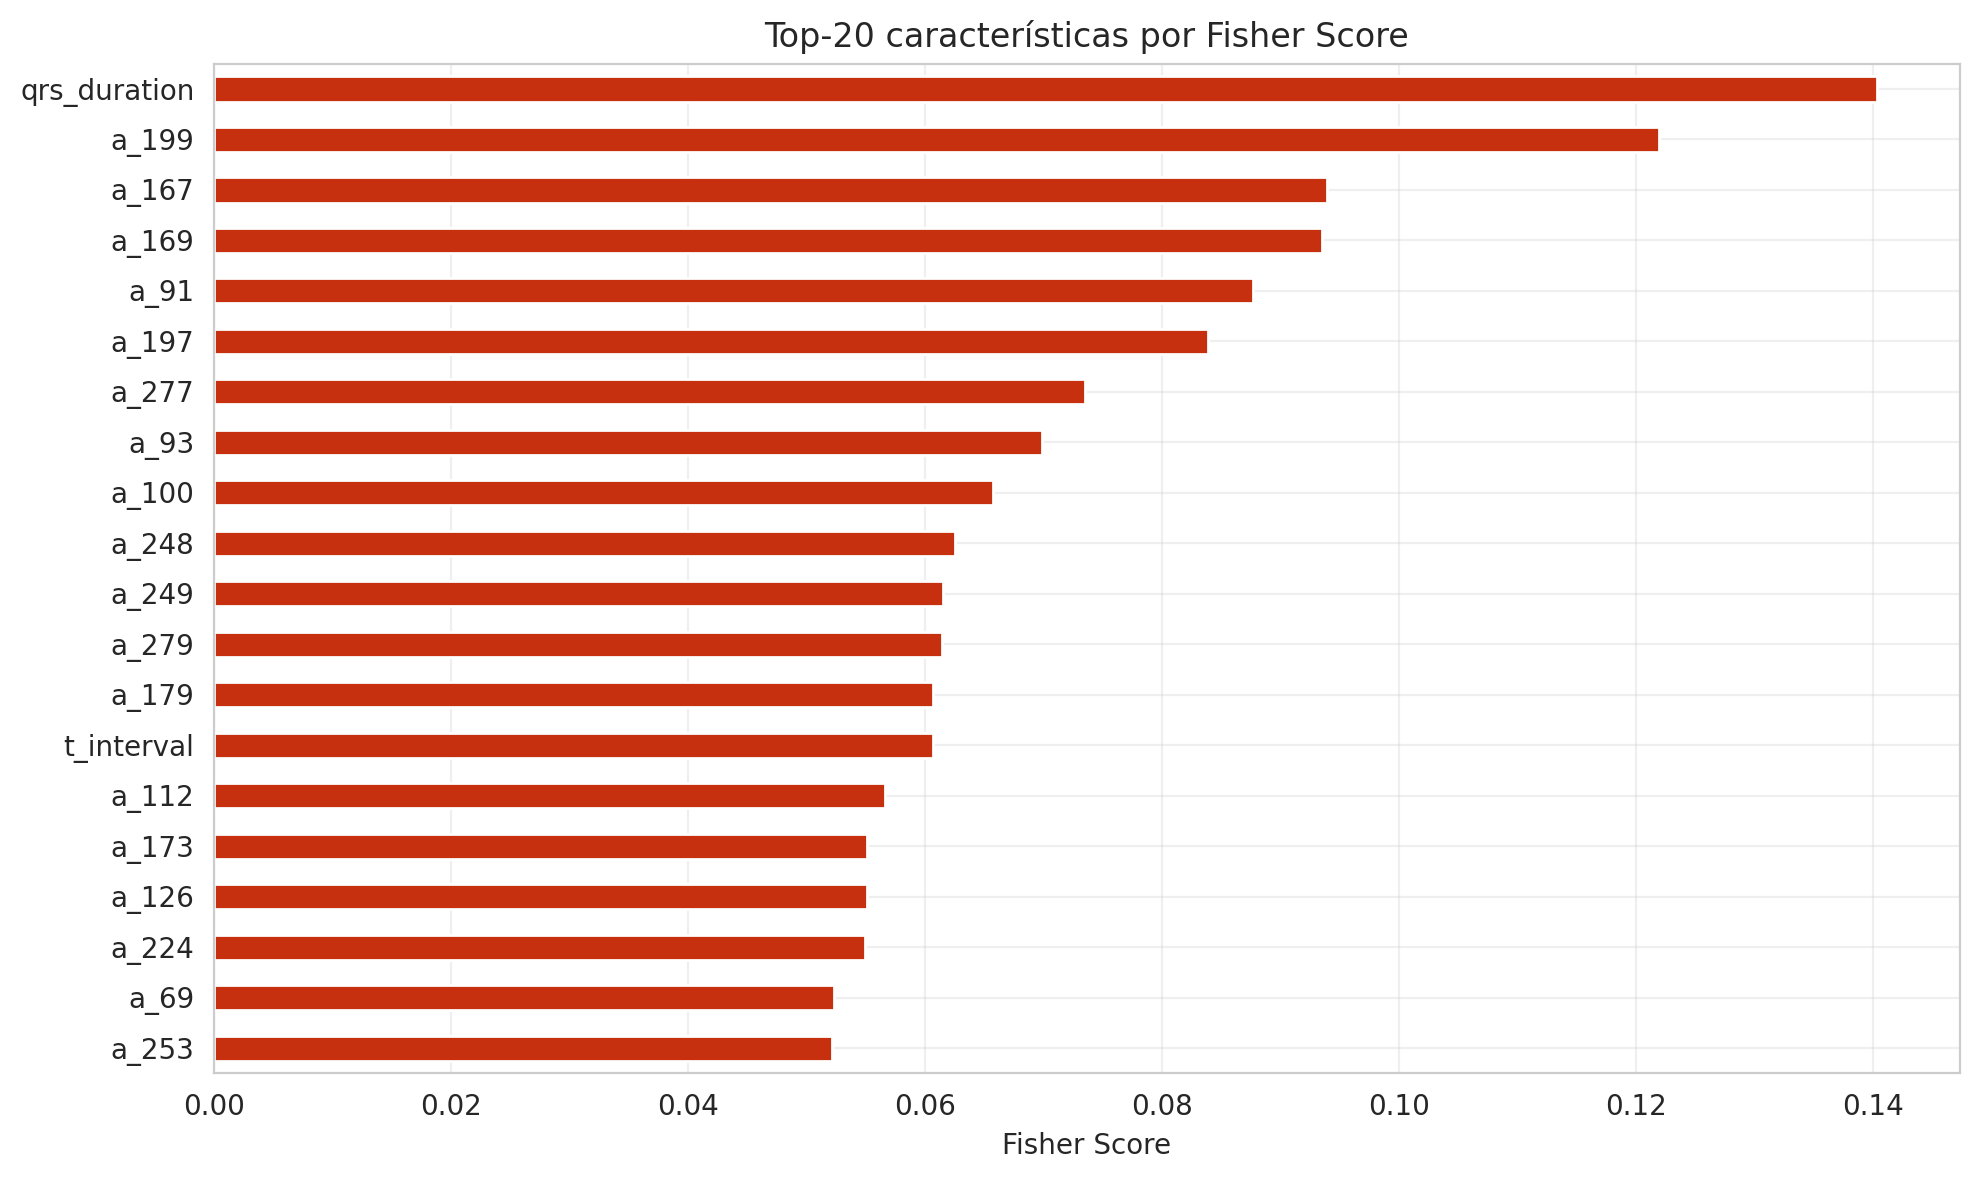

In [129]:
plt.figure(figsize = (10, 6))
fs_ranking.head(20)[::-1].plot(kind = 'barh', color = '#C6300F')
plt.xlabel('Fisher Score')
plt.title('Top-20 características por Fisher Score')
plt.grid(alpha = 0.3)
plt.tight_layout()
guardar_figura('03_fisher_ranking.png')
plt.show()

In [130]:
fisher_cv = cross_val_score(base_svm(), X_train[fisher_features], y_train, cv = cv, scoring = 'accuracy')
print(f'Fisher top-20 — CV accuracy: {fisher_cv.mean():.4f} +/- {fisher_cv.std():.4f}')

Fisher top-20 — CV accuracy: 0.7395 +/- 0.0393


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img/04_fisher_topk.png


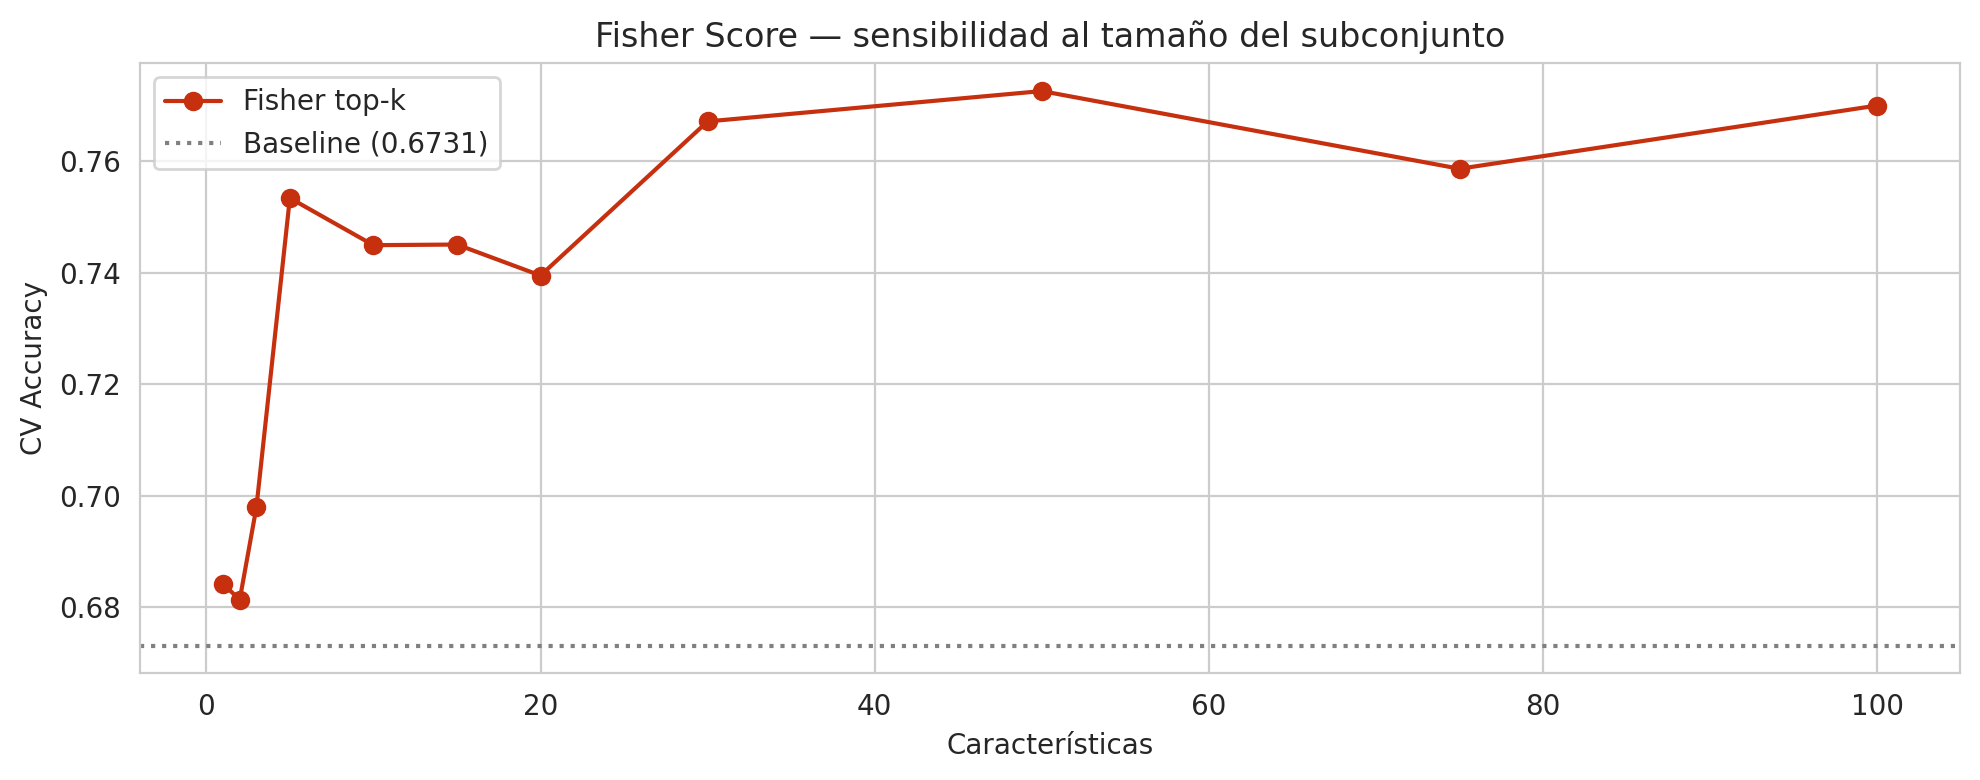

In [140]:
# Sensibilidad al número de características top-k
ks = [1, 2, 3, 5, 10, 15, 20, 30, 50, 75, 100]
fisher_curva = []

for k in ks:

    topk = fs_ranking.head(k).index.tolist()
    s = cross_val_score(
        base_svm(), X_train[topk], y_train,
        cv = cv, scoring = 'accuracy'
    ).mean()
    fisher_curva.append(s)

plt.figure(figsize = (10, 4))
plt.plot(ks, fisher_curva, marker = 'o', color = '#C6300F', label = 'Fisher top-k')
plt.axhline(
    baseline_scores.mean(), color = 'gray', linestyle = ':',
    label = f'Baseline ({baseline_scores.mean():.4f})'
)
plt.xlabel('Características')
plt.ylabel('CV Accuracy')
plt.title('Fisher Score — sensibilidad al tamaño del subconjunto')
plt.legend()
plt.tight_layout()
guardar_figura('04_fisher_topk.png')
plt.show()


## PCA

In [ ]:
# 5.1 Eliminar altas correlaciones (> 0.9)
corr = X_train.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k = 1).astype(bool))

to_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
print(f'Features eliminadas por correlación > 0.9: {len(to_drop)}')
print(f'Quedan: {X_train.shape[1] - len(to_drop)} features')

X_train_dec = X_train.drop(columns = to_drop)
X_test_dec = X_test.drop(columns = to_drop)

Features eliminadas por correlación > 0.9: 24
Quedan: 237 features


Componentes necesarias para 95% de varianza: 94
/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img/05_pca_varianza.png


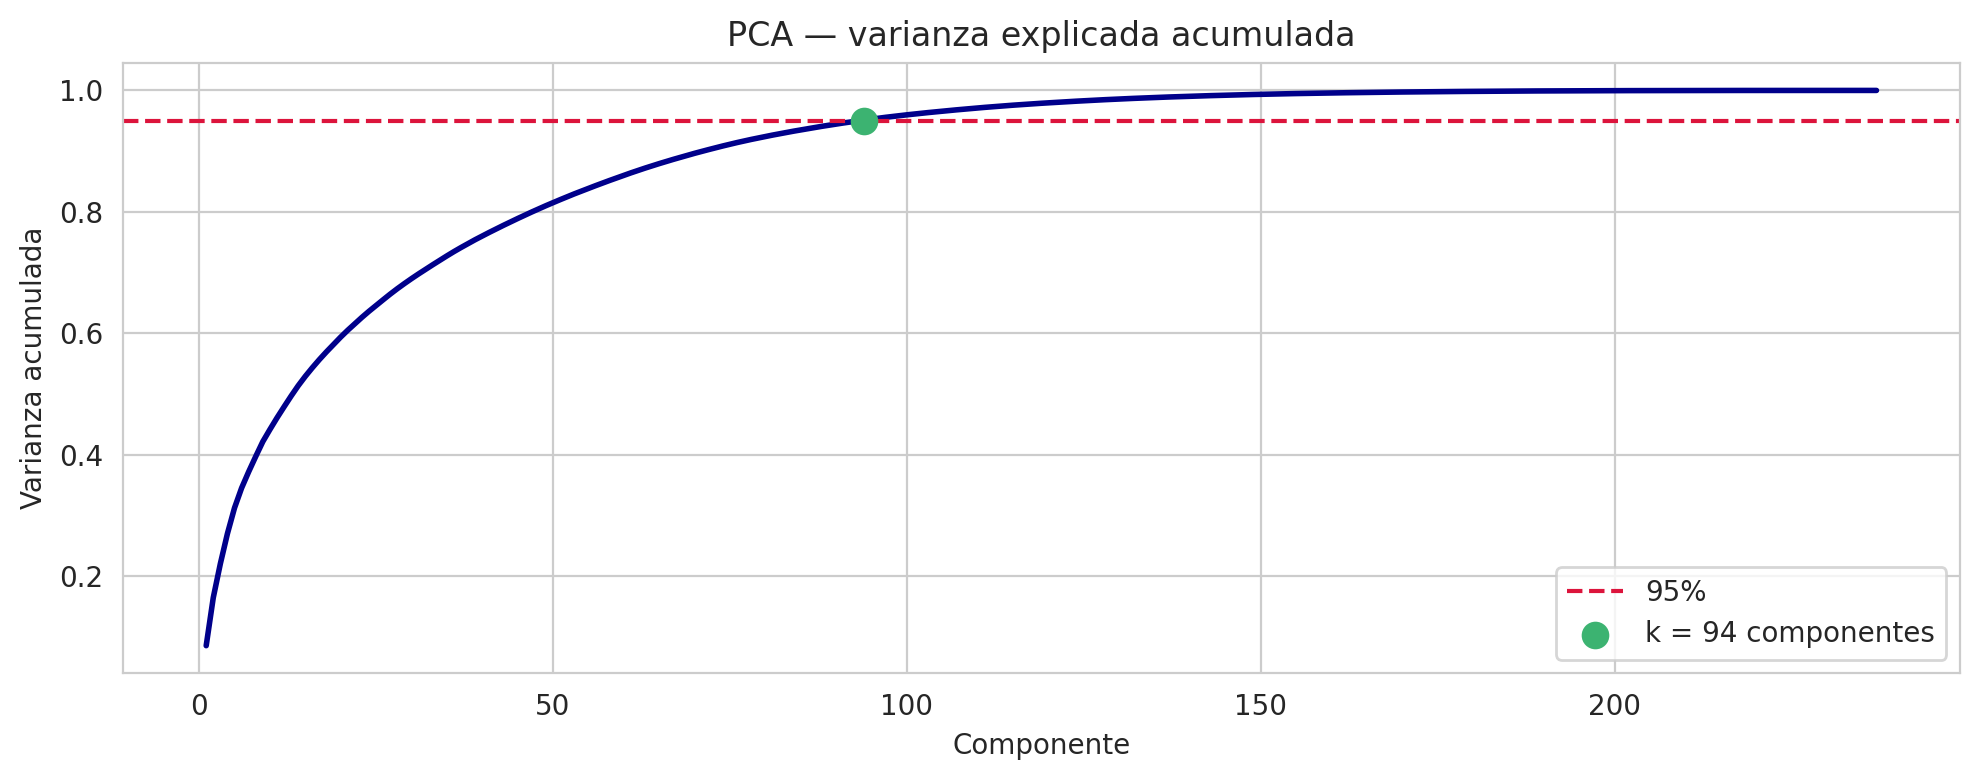

In [164]:
# PCA con 95% de varianza
pca_full = PCA().fit(X_train_dec)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n_comp_95 = int(np.searchsorted(var_acum, 0.95) + 1)
print(f'Componentes necesarias para 95% de varianza: {n_comp_95}')

plt.figure(figsize = (10, 4))
plt.plot(range(1, len(var_acum) + 1), var_acum, linewidth = 2, color = 'darkblue')
plt.axhline(0.95, color = 'crimson', linestyle = '--', label = '95%')
plt.scatter(n_comp_95, 0.95, color = 'mediumseagreen', marker = 'o', zorder = 5, s = 80, label = f'k = {n_comp_95} componentes')
plt.xlabel('Componente')
plt.ylabel('Varianza acumulada')
plt.title('PCA — varianza explicada acumulada')
plt.legend()
plt.tight_layout()
guardar_figura('05_pca_varianza.png')
plt.show()


In [166]:
# 5.3 Ajuste final de PCA y evaluación en CV
pca = PCA(n_components = n_comp_95, random_state = RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_dec)
X_test_pca  = pca.transform(X_test_dec)

pca_cv = cross_val_score(base_svm(), X_train_pca, y_train, cv = cv, scoring = 'accuracy')
print(f'PCA ({n_comp_95} comp.) — CV accuracy: 'f'{pca_cv.mean():.4f} +/- {pca_cv.std():.4f}')

PCA (94 comp.) — CV accuracy: 0.6949 +/- 0.0841


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img/06_pca_2d.png


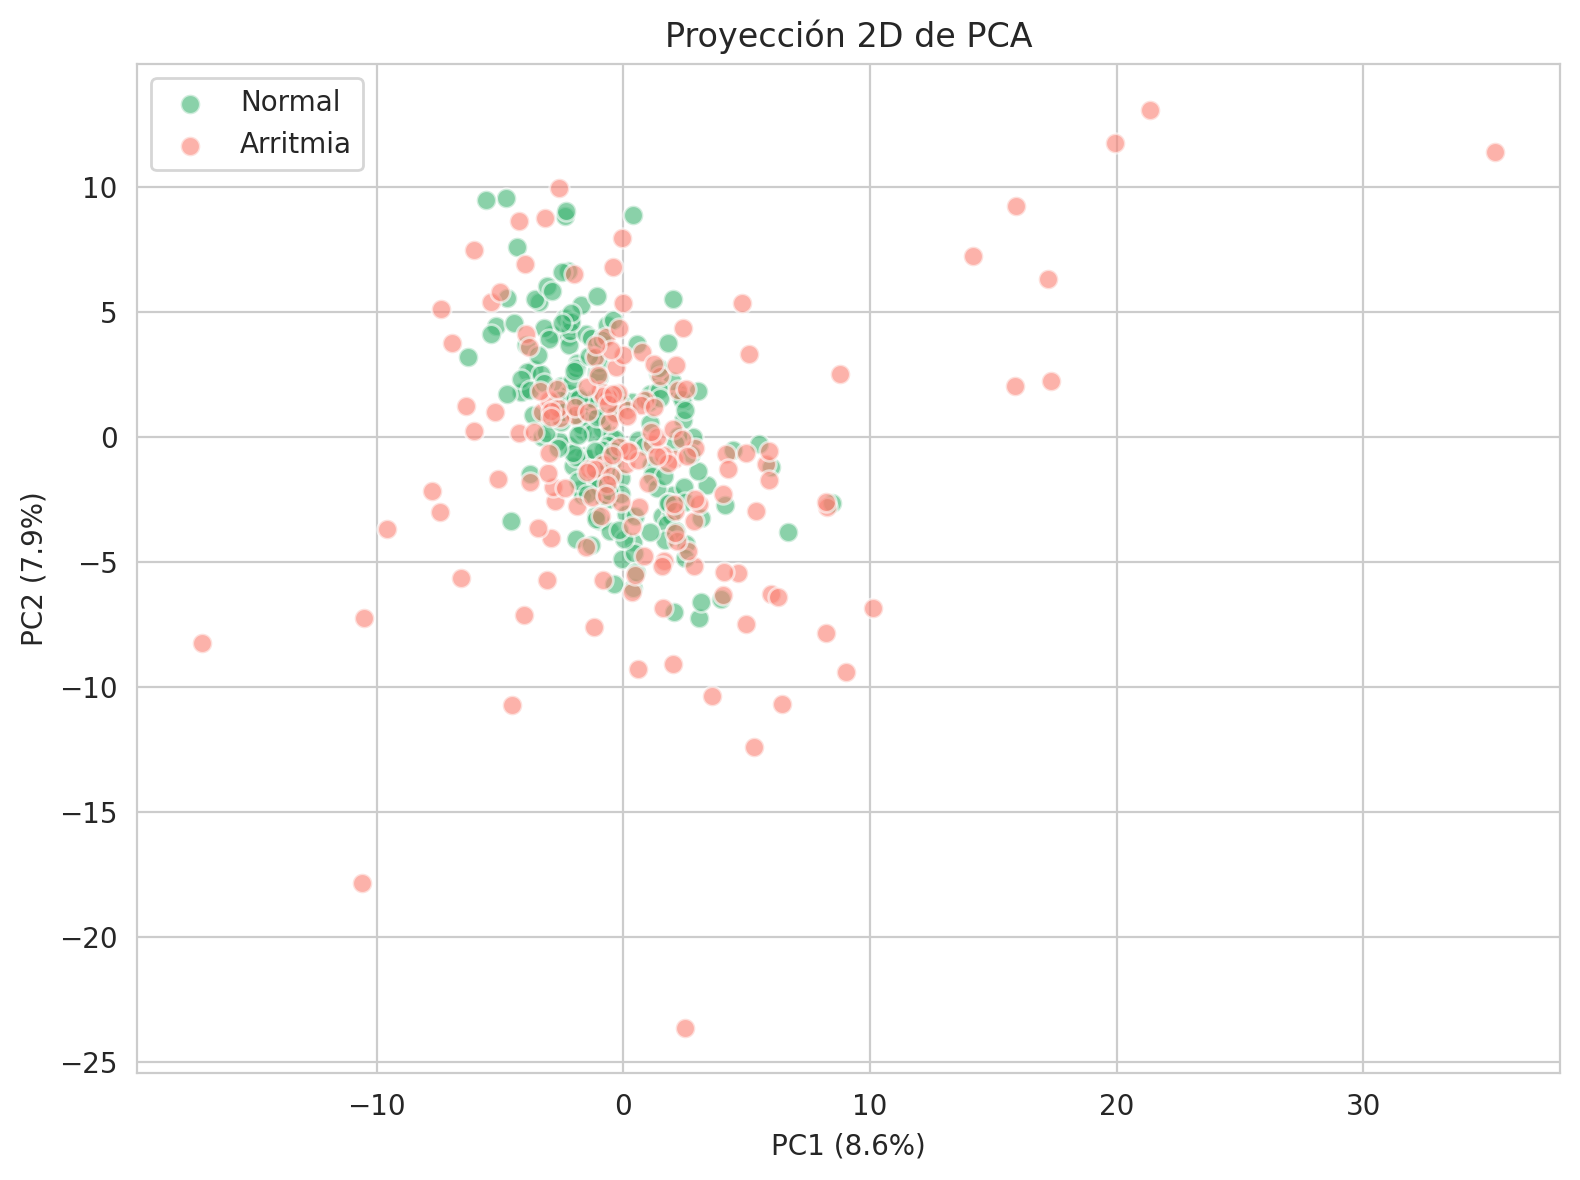

In [167]:
# Proyección 2D
pca2 = PCA(n_components = 2, random_state = RANDOM_STATE).fit(X_train_dec)
X_2d = pca2.transform(X_train_dec)

plt.figure(figsize = (8, 6))

for etiqueta, color, nombre in [(1, 'mediumseagreen', 'Normal'), (0, 'salmon', 'Arritmia')]:

    mascara = y_train == etiqueta
    plt.scatter(
        X_2d[mascara, 0], X_2d[mascara, 1],
        c = color, label = nombre,
        alpha = 0.6, edgecolor = 'white', s = 50)

plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1] * 100:.1f}%)')
plt.title('Proyección 2D de PCA')
plt.legend()
plt.tight_layout()
guardar_figura('06_pca_2d.png')
plt.show()


In [ ]:
def evaluar(X_tr, X_te, y_tr, y_te, nombre):

    clf = base_svm().fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)

    try:

        auc = roc_auc_score(y_te, clf.decision_function(X_te))

    except Exception:

        auc = np.nan

    return {
        'Método': nombre,
        'Nº features': X_tr.shape[1],
        'Test Accuracy': acc,
        'Test AUC': auc,
        'clf': clf,
        'pred': y_pred,
    }

resultados = []
resultados.append(evaluar(
    X_train, X_test, y_train, y_test,
    'Baseline (todas)'
))
resultados.append(evaluar(
    X_train[sfs_features], X_test[sfs_features], y_train, y_test,
    f'SFS manual ({len(sfs_features)})'
))
resultados.append(evaluar(
    X_train[sfs_sk_features], X_test[sfs_sk_features], y_train, y_test,
    f'SFS sklearn ({len(sfs_sk_features)})'
))
resultados.append(evaluar(
    X_train[fisher_features], X_test[fisher_features], y_train, y_test,
    'Fisher (20)'
))
resultados.append(evaluar(
    X_train_pca, X_test_pca, y_train, y_test,
    f'PCA ({n_comp_95})'
))

tabla = pd.DataFrame(
    [{k: v for k, v in r.items() if k not in ('clf', 'pred')} for r in resultados]
)
tabla[['Test Accuracy', 'Test AUC']] = tabla[['Test Accuracy', 'Test AUC']].round(4)
tabla


,Método,Nº features,Test Accuracy,Test AUC
0,Baseline (todas),261,0.6484,0.6905
1,SFS manual (9),9,0.7143,0.7590
2,SFS sklearn (7),7,0.7143,0.7585
3,Fisher (20),20,0.7582,0.7638
4,PCA (94),94,0.6703,0.6424


/home/ibra/IIMAS/Sexto/Reconocimiento de Patrones/Prácticas/P3/Reporte/Img/07_matrices_confusion.png


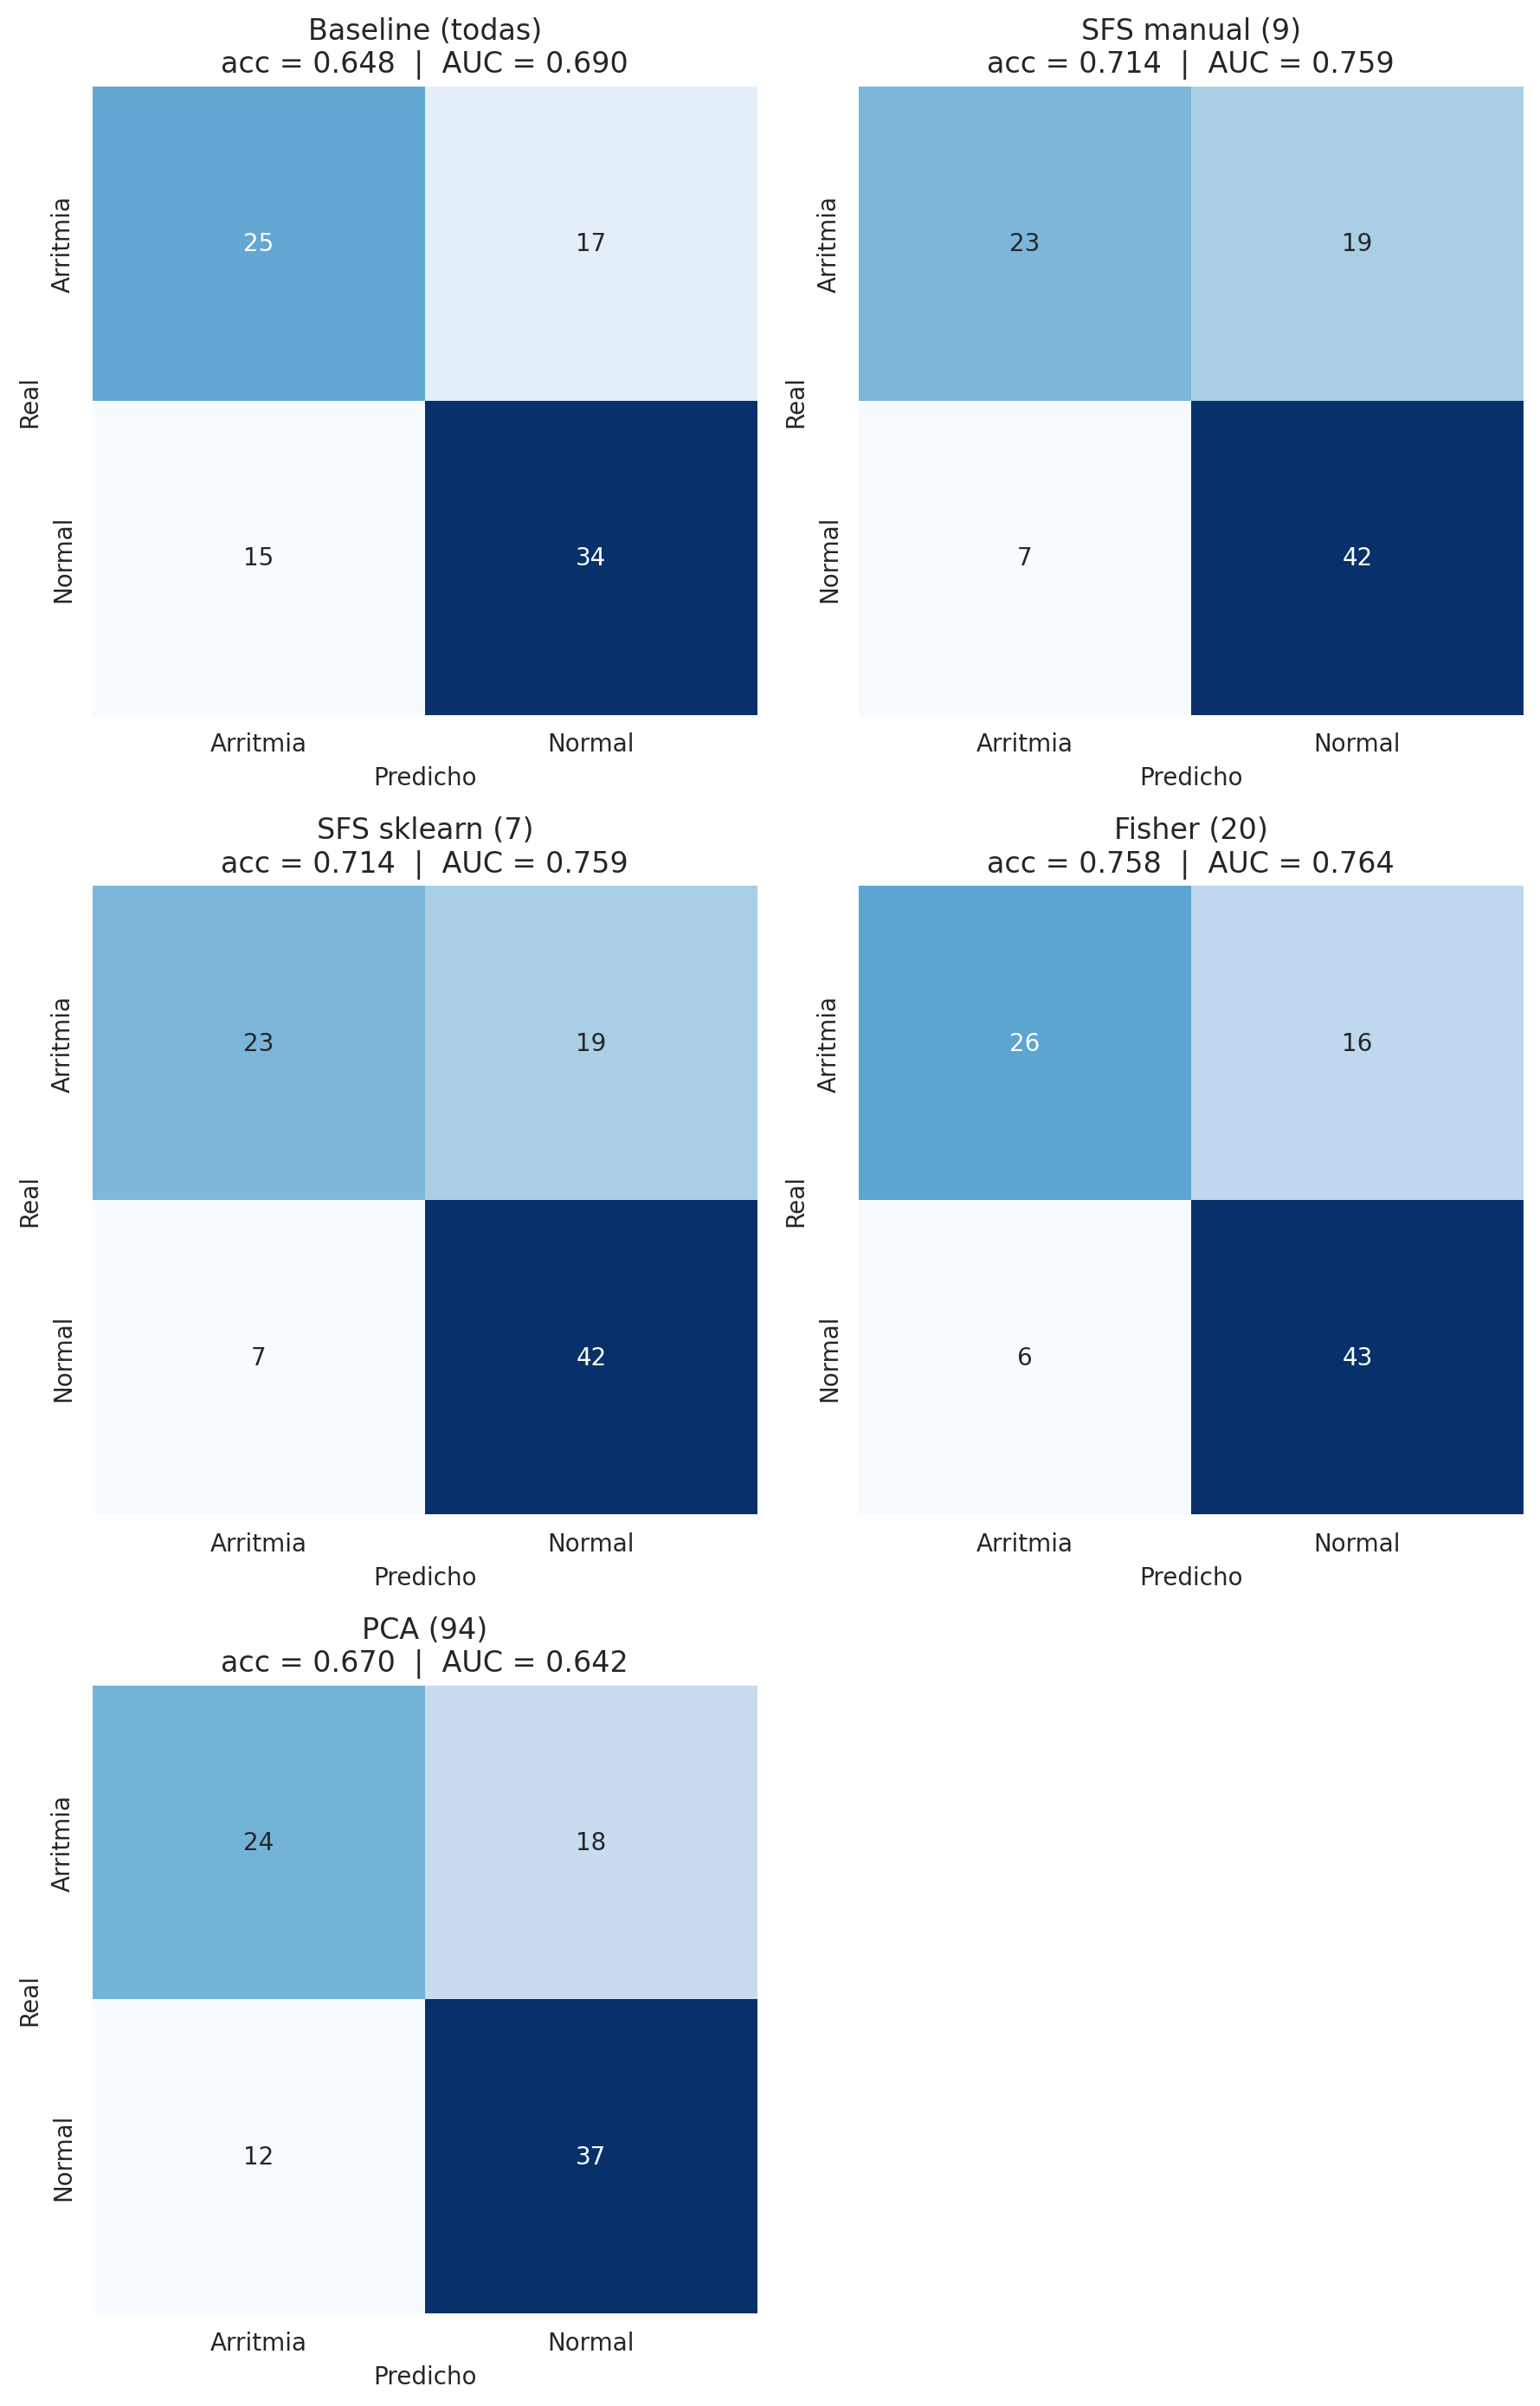

In [137]:
# Matrices de confusión para los 5 métodos
fig, axes = plt.subplots(3, 2, figsize = (9, 14))
axes = axes.flatten()

for ax, r in zip(axes, resultados):

    cm = confusion_matrix(y_test, r['pred'])
    sns.heatmap(
        cm, annot = True, fmt = 'd', cmap = 'Blues', ax = ax, cbar = False,
        xticklabels = ['Arritmia', 'Normal'],
        yticklabels = ['Arritmia', 'Normal'],
    )
    ax.set_title(f"{r['Método']}\nacc = {r['Test Accuracy']:.3f}  |  AUC = {r['Test AUC']:.3f}")
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

if len(resultados) < len(axes):

    for i in range(len(resultados), len(axes)):

        axes[i].axis('off')

plt.tight_layout()
guardar_figura('07_matrices_confusion.png')
plt.show()

In [138]:
# Comparación de las features elegidas por los tres métodos supervisados
set_manual = set(sfs_features)
set_sklearn = set(sfs_sk_features)
set_fisher = set(fisher_features)

print('Comparaciones')
print(f'SFS manual: {len(set_manual)} features')
print(f'SFS sklearn: {len(set_sklearn)} features')
print(f'Fisher top: {len(set_fisher)} features')
print(f'Manual con sklearn: {sorted(set_manual & set_sklearn)}')
print(f'Manual con Fisher: {sorted(set_manual & set_fisher)}')
print(f'sklearn con Fisher: {sorted(set_sklearn & set_fisher)}')
print(f'Intersección de los tres: {sorted(set_manual & set_sklearn & set_fisher)}')


Comparaciones
SFS manual: 9 features
SFS sklearn: 7 features
Fisher top: 20 features
Manual con sklearn: ['a_103', 'a_114', 'a_169', 'a_250', 'a_44', 'a_61', 'qrs_duration']
Manual con Fisher: ['a_169', 'qrs_duration']
sklearn con Fisher: ['a_169', 'qrs_duration']
Intersección de los tres: ['a_169', 'qrs_duration']
